# Линейная регрессия
__Суммарное количество баллов: 10__

In [1]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import copy

In [2]:
def read_data(path="boston.csv"):
    dataframe = np.genfromtxt(path, delimiter=",", skip_header=15)
    np.random.seed(42)
    np.random.shuffle(dataframe)
    X = dataframe[:, :-1]
    y = dataframe[:, -1]
    return X, y

In [3]:
def generate_synthetic(size:int, dim=6, noise=0.1):
    X = np.random.randn(size, dim)
    w = np.random.randn(dim + 1)
    noise = noise * np.random.randn(size)
    y = X.dot(w[1:]) + w[0] + noise
    return X, y

### Задание 1 (1 балл)
Для начала нужно понять, какую метрику для ошибки будем использовать. В нашем случае нам подойдет стандартная метрика MSE. Также чтобы оценить качество модели нам понадобится метрика $R^2$. Реализуйте обе эти метрики.

In [4]:
from task import mse, r2

### Задание 2 (3 балла)
Теперь реализуем линейную регрессию при помощи явного решения задачи минимизации. 

#### Методы
`fit(X, y)` - решает задачу минимизации $\arg\min_{w, b}\sum ((w\cdot x + b) - y)^2$. 

`predict(X)` - строит предсказание `y` для объектов из `X`.

In [5]:
from task import NormalLR

In [6]:
X, y = generate_synthetic(1024)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8)

In [7]:
regr = NormalLR()
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)
print(f"MSE: {mse(y_test, y_pred)}, R2: {r2(y_test, y_pred)}")

MSE: 0.008329482594582147, R2: 0.9976776593812805


### Задание 3 (4 балла)
Теперь реализуем линейную регрессию с использованием градиентного спуска с learning rate `alpha` в течении `iterations` итераций. В задании необходимо использовать регуляризацию Лассо с коэффициентом `l`.

#### Методы
`fit(X, y)` - приближает решение задачи минимизации $\arg\min_{w, b}\sum ((w\cdot x + b) - y)^2$ при помощи градиентного спуска. 


`predict(X)` - строит предсказание `y` для объектов из `X`.

In [8]:
from task import GradientLR

In [9]:
def build_plot(X_train, y_train, X_test, y_test):
    xs = np.arange(0.0, 0.02, 0.0002)
    errors = []
    for x in xs:
        regr = GradientLR(0.1, iterations=10000, l=x)
        regr.fit(X_train, y_train)
        errors.append(mse(y_test, regr.predict(X_test)))
    plt.figure(figsize=(9, 4))
    plt.xlim(xs[0], xs[-1])
    plt.grid()
    plt.plot(xs, errors)
    plt.show()

In [10]:
X, y = generate_synthetic(1024)
X, X_val, y, y_val = train_test_split(X, y, train_size=0.9, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True)

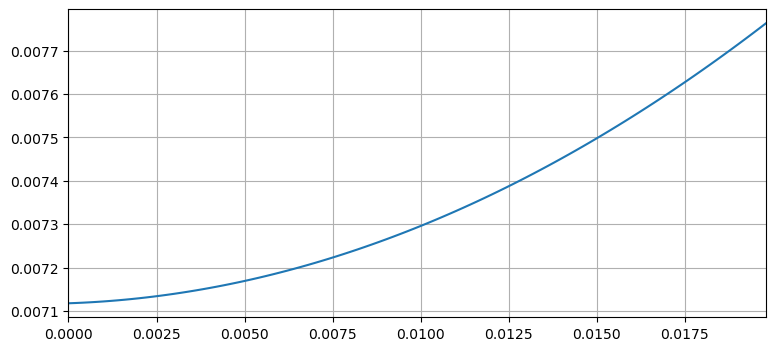

In [11]:
build_plot(X_train, y_train, X_val, y_val)

In [12]:
regr = GradientLR(0.1, iterations=10000)
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)
print(f"MSE: {mse(y_test, y_pred)}, R2: {r2(y_test, y_pred)}")

MSE: 0.010208391925017914, R2: 0.9987877045034526


### Задание 4 (2 балла)
Линейная регрессия является методом, который можно интерпретировать основываясь на значениях весов модели. Реализуйте метод, который будет упорядочивать признаки по их важности от наибольшей важности к наименьшей.

Обратите внимание, что такая интерпретация имеет смысл только если данные предварительно нормализованы, а также в признаках нет мультиколлинеарности (если используете обычную линейную регрессию).

#### Методы
`get_feature_importance` - метод, который вычисляет важность для каждого признака. Принимает на вход обученную линейную регрессию, возвращает список значений метрики важности признаков.

`get_most_important_features`- метод, который упорядочевает признаки по их важности в порядке убывания. Принимает на вход обученную линейную регрессию, возвращает упорядоченный список, состоящий из индексов признаков.

In [13]:
from task import get_feature_importance, get_most_important_features

In [14]:
regr = NormalLR()
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)

print(get_feature_importance(regr))
print(get_most_important_features(regr))

[0.08860837 0.28738108 0.23520211 0.0871337  0.10785579 0.19381895]
[1, 2, 5, 4, 0, 3]


In [15]:
a = [0.0694447, 0.26671751, 0.18147685, 0.04104185, 0.16884088, 0.20034687, 0.07213134]

In [16]:
a

[0.0694447,
 0.26671751,
 0.18147685,
 0.04104185,
 0.16884088,
 0.20034687,
 0.07213134]

In [17]:
a[:-1]

[0.0694447, 0.26671751, 0.18147685, 0.04104185, 0.16884088, 0.20034687]

In [18]:
X_test

array([[ 0.42113977, -0.82631408, -0.82130163,  0.82561028, -0.33465168,
         0.45787679],
       [ 0.0271319 ,  0.40981406, -0.4261667 ,  0.2994821 ,  1.16829227,
        -0.96500168],
       [-1.18173571,  2.32046299,  0.92618633, -0.70447768, -1.44525667,
         0.68257561],
       ...,
       [-1.5493852 , -0.35709155, -1.22862965, -0.54258246, -0.99366871,
        -0.43978774],
       [ 0.33847686,  1.93096826, -0.21567257,  1.29570414, -0.40062299,
         0.38285605],
       [-0.30625535,  0.77120453, -0.10129081,  1.1043211 ,  1.10759683,
        -1.7767413 ]])

In [19]:
regr = GradientLR(0.1, iterations=10000)
regr.fit(X_train, y_train)
y_pred = regr.predict(X_test)

print(get_feature_importance(regr))
print(get_most_important_features(regr))

[0.08860837 0.28738108 0.23520211 0.0871337  0.10785579 0.19381895]
[1, 2, 5, 4, 0, 3]


### Дополнительно
Протесируйте оба метода на данных `boston.csv`, для градиентного спуска постройте график зависимости ошибки от коэффициента регуляризации. 

In [20]:
X, y = read_data()
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.8, shuffle=False)

In [28]:
X_train

array([[9.1780e-02, 0.0000e+00, 4.0500e+00, ..., 1.6600e+01, 3.9550e+02,
        9.0400e+00],
       [5.6440e-02, 4.0000e+01, 6.4100e+00, ..., 1.7600e+01, 3.9690e+02,
        3.5300e+00],
       [1.0574e-01, 0.0000e+00, 2.7740e+01, ..., 2.0100e+01, 3.9011e+02,
        1.8070e+01],
       ...,
       [3.0410e-02, 0.0000e+00, 5.1900e+00, ..., 2.0200e+01, 3.9481e+02,
        1.0560e+01],
       [5.2058e-01, 0.0000e+00, 6.2000e+00, ..., 1.7400e+01, 3.8845e+02,
        9.5400e+00],
       [2.5199e-01, 0.0000e+00, 1.0590e+01, ..., 1.8600e+01, 3.8943e+02,
        1.8060e+01]])

In [24]:
regr = NormalLR()
regr.fit(X_train, y_train)
print(f"MSE: {mse(y_val, regr.predict(X_val))}, R2: {r2(y_val, regr.predict(X_val))}")

MSE: 22266311.080831815, R2: 0.6872797475661765


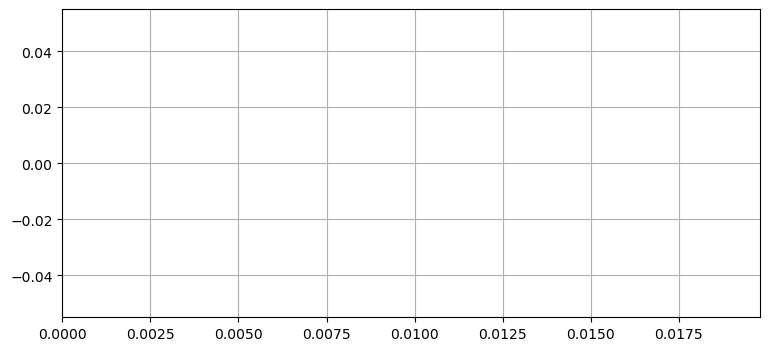

In [25]:
build_plot(X_train, y_train, X_val, y_val)

In [26]:
regr = GradientLR(0.1, iterations=10000)
regr.fit(X_train, y_train)
print(f"MSE: {mse(y_val, regr.predict(X_val))}, R2: {r2(y_val, regr.predict(X_val))}")

MSE: nan, R2: nan


Проинтерпритируйте полученные результаты. Опишите влияние каждого признака на результат предсказания.